In [1]:
from two_D_project import Two_D_test, Particle_config
import numpy as np
import pickle as pkl
from matplotlib import pyplot as plt
from joblib import Parallel, delayed

In [ ]:
np.random.seed(13) # We set a seed for reproductibility

N = 1000    # Number of particles
sigma_0 = 1.0  # Setting the hard core according to recommendation
sigma_1 = 2.5  # Same with the soft shoulder
epsilon = 1.0  # Set the energy to unit also
T_target = 0.1  # Target production temperature
cap = 800  # Max potential instead of infinity
max_step_size = 0.5  # Max step size for the MCMC

In [3]:
# Functions to save and read objets from .pkl files
def save_pkl(obj, filename):
    with open(filename, 'wb') as outp:
        pkl.dump(obj, outp, pkl.HIGHEST_PROTOCOL)

def load_pkl(filename):
    with open(filename, "rb") as inp:
        o = pkl.load(inp)
    return o

In [4]:
# Make a list of particle config objects
rhos = [0.10, 0.15, 0.227, 0.291, 0.38]
Lengths = [np.sqrt(N / rho) for rho in rhos]
max_step_sizes = [1.1, 0.338, 0.200, 0.146, 0.107] # precomputed max step sizes for each density

# For all the simulations we can use the same Particle_config array since running the simulation in parallel
# does not change the objects, but rather returns the changed ones
pcs1 = [Particle_config(N=N,
                        rho=rhos[i],
                        L=Lengths[i],
                        sigma_0=sigma_0,
                        sigma_1=sigma_1,
                        epsilon=epsilon,
                        T_target=T_target,
                        cap=cap, # energy cap only valid for the pre-eq step
                        max_step_size=max_step_sizes[i])
        for i in range(len(rhos))]

In [5]:
pc1 = pcs1[1]

In [ ]:
sim = Two_D_test(pc1)
pc1.cold_start_hex_grid_config()
sim.run_simulation(n_iter=20000000)

Running Simulation: 100%|██████████| 20000000/20000000 [57:50<00:00, 5762.45it/s] 


(0.2801669, 0.0)

In [6]:
pc2 = Particle_config(N=N,
                        rho=rhos[1],
                        L=Lengths[1],
                        sigma_0=sigma_0,
                        sigma_1=sigma_1,
                        epsilon=epsilon,
                        T_target=T_target,
                        cap=cap, # energy cap only valid for the pre-eq step
                        max_step_size=max_step_sizes[1])

pc3 = Particle_config(N=N,
                        rho=rhos[1],
                        L=Lengths[1],
                        sigma_0=sigma_0,
                        sigma_1=sigma_1,
                        epsilon=epsilon,
                        T_target=T_target,
                        cap=cap, # energy cap only valid for the pre-eq step
                        max_step_size=max_step_sizes[1])

pcs2 = [pc1, pc2]

In [18]:
def run_simulation_comp(p, i):
    sim = Two_D_test(p)

    # if i==0:
    #     p.cold_start_ort_grid_config()
    #     print(i)
    # elif i==1:
    #     print(i)
    #     p.hot_start_config()
    #     sim.pre_equilibrate()
    acceptance_rate, accumulation_err = sim.run_simulation(n_iter=10000000, sample_interval=1000, new_start=False)

    return p, acceptance_rate, accumulation_err

In [19]:
# objects in pcs are not modified, the resulting objects in res_pcs are modified
results = Parallel(n_jobs=len(res))(delayed(run_simulation_comp)(p,i) for i, p in enumerate(res))

In [21]:
res = [r[0] for r in results]

In [ ]:
pc1.U_samples

array([], dtype=float64)

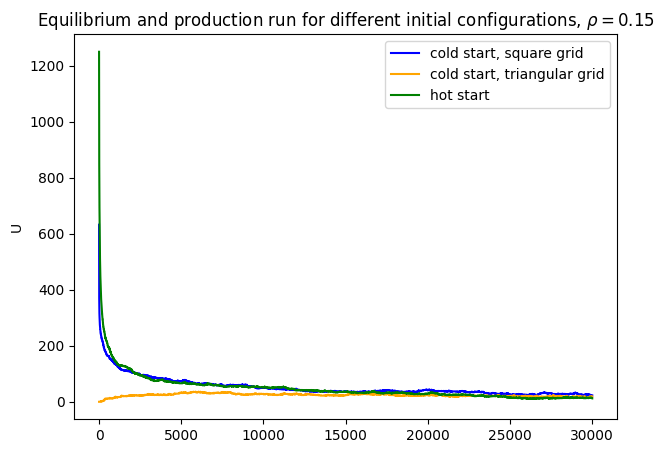

In [45]:
colors = ["blue", "orange", "green"]
leg = ["cold start, square grid", "cold start, triangular grid", "hot start"]
post_eq = 12500

plt.figure(figsize=(7,5))
for i,p in enumerate(res):
    U = p.U_samples[:]
    c = colors[i]
    # m = np.mean(U[post_eq:])
    # plt.hlines(m, 0, len(U), colors=c, linestyles="--")
    plt.plot(U, color=c)

plt.title(f"Equilibrium and production run for different initial configurations, $\\rho = 0.15$")
plt.ylabel("U")
plt.legend(leg)
# plt.vlines(post_eq, 0, 120, linestyles="--", colors="black")

In [ ]:
eq_run_res = [res, results[0][0], results[1][0]]
save_pkl(eq_run_res, "eq_run_res.pkl")

In [8]:
res = load_pkl("eq_run_res.pkl")